In [4]:
import nfl_data_py as nfl, pandas as pd, os

In [5]:
# for x in [2021,2022,2023]:
#     print("getting data for {}",str(x))
#     data = nfl.import_pbp_data([x], downcast=True, alt_path=None)
#     data.to_parquet("{}_pbp.parquet".format(str(x)))


lets try to calculate average yards thrown per touchdown metric
play+type = pass, run

In [6]:
df_2023 = pd.read_parquet('2023_pbp.parquet')
# df_2022 = df_2022[df_2022['passer'].notnull()]
# df_2022[[
#     'passer','touchdown','pass_touchdown','rush_touchdown','play_type','yards_gained','air_yards','yards_after_catch','interception'
# ]]

In [7]:
df_grouped = df_2023.groupby('passer')['yards_gained'].sum()
df_grouped = df_grouped[df_grouped > 100]
df_grouped


passer
A.Dalton         344.0
A.Richardson     287.0
B.Mayfield       650.0
B.Purdy          730.0
B.Young          322.0
C.Stroud         846.0
D.Carr           570.0
D.Jones          575.0
D.Prescott       661.0
D.Ridder         489.0
D.Watson         662.0
G.Minshew II     362.0
G.Smith          707.0
J.Allen          782.0
J.Burrow         530.0
J.Dobbs          543.0
J.Fields         528.0
J.Garoppolo      705.0
J.Goff          1013.0
J.Herbert        907.0
J.Hurts          630.0
J.Love           906.0
K.Cousins       1033.0
K.Pickett        640.0
L.Jackson        692.0
M.Jones          748.0
M.Stafford       885.0
P.Mahomes        904.0
R.Tannehill      454.0
R.Wilson         776.0
S.Howell         589.0
T.Lawrence       766.0
T.Tagovailoa    1030.0
Z.Wilson         454.0
Name: yards_gained, dtype: float32

In [8]:
df_grouped_td = df_2023.groupby('passer')['touchdown'].sum()
df_grouped_td = df_grouped_td[df_grouped_td > 0]
df_grouped_td


passer
A.Dalton        2.0
A.Richardson    1.0
B.Mayfield      4.0
B.Purdy         4.0
B.Young         2.0
C.Stroud        4.0
D.Carr          2.0
D.Jones         3.0
D.Prescott      3.0
D.Ridder        2.0
D.Watson        6.0
G.Minshew II    2.0
G.Smith         4.0
J.Allen         6.0
J.Burrow        2.0
J.Dobbs         3.0
J.Fields        6.0
J.Garoppolo     5.0
J.Goff          7.0
J.Herbert       6.0
J.Hurts         3.0
J.Love          8.0
K.Allen         1.0
K.Cousins       9.0
K.Pickett       4.0
L.Jackson       2.0
M.Jones         6.0
M.Stafford      2.0
M.White         1.0
P.Mahomes       8.0
R.Tannehill     1.0
R.Wilson        6.0
S.Howell        6.0
T.Lawrence      4.0
T.Tagovailoa    8.0
Z.Wilson        2.0
Name: touchdown, dtype: float32

In [9]:
df_ratio = df_grouped_td.to_frame().merge(df_grouped.to_frame(), on='passer')
df_ratio['yards_per_touchdown'] = df_ratio['yards_gained'] / df_ratio['touchdown']
df_ratio = df_ratio.sort_values('yards_per_touchdown')


In [10]:
# EDA on df_ratio
df_ratio.describe()


,touchdown,yards_gained,yards_per_touchdown
count,34.000000,34.000000,34.000000
mean,4.205883,668.235291,192.360062
std,2.253340,202.111740,87.884575
min,1.000000,287.000000,88.000000
25%,2.000000,533.250000,129.583328
50%,4.000000,661.500000,174.375000
75%,6.000000,780.500000,218.124996
max,9.000000,1033.000000,454.000000


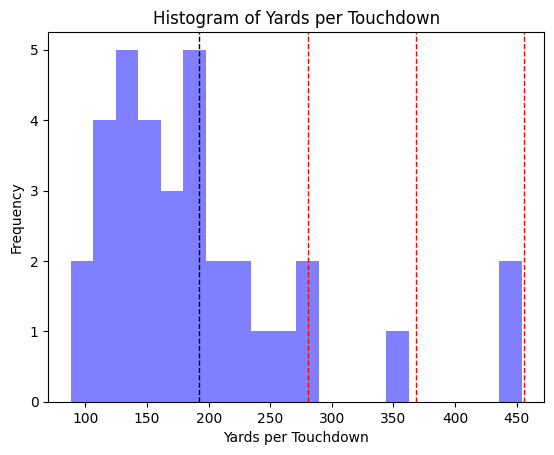

In [36]:
import matplotlib.pyplot as plt

mean = df_ratio['yards_per_touchdown'].mean()
std = df_ratio['yards_per_touchdown'].std()

plt.hist(df_ratio['yards_per_touchdown'], bins=20, alpha=0.5, color='blue')
plt.axvline(mean, color='black', linestyle='dashed', linewidth=1)
plt.axvline(mean + std, color='red', linestyle='dashed', linewidth=1)
plt.axvline(mean + 2*std, color='red', linestyle='dashed', linewidth=1)
plt.axvline(mean + 3*std, color='red', linestyle='dashed', linewidth=1)

plt.xlabel('Yards per Touchdown')
plt.ylabel('Frequency')
plt.title('Histogram of Yards per Touchdown')

plt.show()


In [12]:
# for x in nfl.see_pbp_cols():
#     print(x)

play_id
game_id
old_game_id
home_team
away_team
season_type
week
posteam
posteam_type
defteam
side_of_field
yardline_100
game_date
quarter_seconds_remaining
half_seconds_remaining
game_seconds_remaining
game_half
quarter_end
drive
sp
qtr
down
goal_to_go
time
yrdln
ydstogo
ydsnet
desc
play_type
yards_gained
shotgun
no_huddle
qb_dropback
qb_kneel
qb_spike
qb_scramble
pass_length
pass_location
air_yards
yards_after_catch
run_location
run_gap
field_goal_result
kick_distance
extra_point_result
two_point_conv_result
home_timeouts_remaining
away_timeouts_remaining
timeout
timeout_team
td_team
td_player_name
td_player_id
posteam_timeouts_remaining
defteam_timeouts_remaining
total_home_score
total_away_score
posteam_score
defteam_score
score_differential
posteam_score_post
defteam_score_post
score_differential_post
no_score_prob
opp_fg_prob
opp_safety_prob
opp_td_prob
fg_prob
safety_prob
td_prob
extra_point_prob
two_point_conversion_prob
ep
epa
total_home_epa
total_away_epa
total_home_rush_epa


In [14]:
#nfl.import_weekly_data([2023], downcast=True).query("player_id=='00-0026498'")

Downcasting floats.


,player_id,player_name,player_display_name,position,position_group,headshot_url,recent_team,season,week,season_type,...,receiving_first_downs,receiving_epa,receiving_2pt_conversions,racr,target_share,air_yards_share,wopr,special_teams_tds,fantasy_points,fantasy_points_ppr
1,00-0026498,M.Stafford,Matthew Stafford,QB,QB,https://static.www.nfl.com/image/private/f_aut...,LA,2023,1,REG,...,0.0,NaN,0,NaN,NaN,NaN,NaN,0.0,14.46,14.46
2,00-0026498,M.Stafford,Matthew Stafford,QB,QB,https://static.www.nfl.com/image/private/f_aut...,LA,2023,2,REG,...,0.0,NaN,0,NaN,NaN,NaN,NaN,0.0,13.98,13.98
3,00-0026498,M.Stafford,Matthew Stafford,QB,QB,https://static.www.nfl.com/image/private/f_aut...,LA,2023,3,REG,...,0.0,NaN,0,NaN,NaN,NaN,NaN,0.0,11.46,11.46


In [20]:
qb_weekly = nfl.import_weekly_data([2023]).query("position=='QB'")
qb_weekly_grouped = qb_weekly.groupby('player_name')['fantasy_points_ppr'].mean()
qb_weekly_grouped = qb_weekly_grouped[qb_weekly_grouped >= 5]
qb_weekly_grouped.sort_values(ascending=True)



Downcasting floats.


player_name
B.Gabbert       -2.860000
K.Allen         -0.200000
S.Darnold       -0.150000
J.Browning      -0.100000
A.Rodgers        0.000000
C.Rush           0.000000
S.Clifford       0.000000
T.Taylor         0.220000
C.Beathard       0.360000
J.Winston        4.040000
T.Hill           4.073333
M.White          6.580000
Z.Wilson         7.660000
G.Minshew        8.073334
J.Burrow         8.906667
R.Tannehill      9.206667
D.Carr           9.813334
B.Young         10.530001
D.Ridder        12.206666
S.Howell        12.346667
K.Pickett       12.820000
D.Jones         13.060000
M.Stafford      13.300000
J.Fields        13.313333
J.Garoppolo     13.420001
D.Prescott      13.426666
T.Lawrence      13.780000
B.Mayfield      14.813333
J.Dobbs         15.086666
G.Smith         15.880000
J.Goff          16.590000
M.Jones         17.073334
B.Purdy         17.279999
C.Stroud        17.580000
D.Watson        17.806665
R.Wilson        18.446667
J.Allen         18.673334
J.Hurts         19.199999


In [23]:
qb_weekly_grouped.describe()

count    46.000000
mean     11.914275
std       7.785178
min      -2.860000
25%       6.850000
50%      13.306666
75%      17.749999
max      24.120001
Name: fantasy_points_ppr, dtype: float64

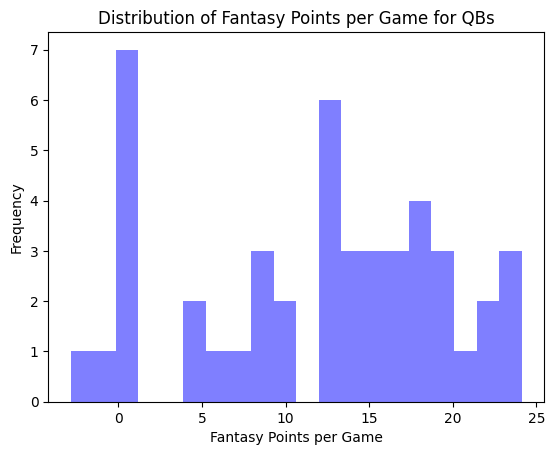

In [25]:

import matplotlib.pyplot as plt
plt.hist(qb_weekly_grouped, bins=20, alpha=0.5, color='blue')
plt.xlabel('Fantasy Points per Game')
plt.ylabel('Frequency')
plt.title('Distribution of Fantasy Points per Game for QBs')
plt.show()
